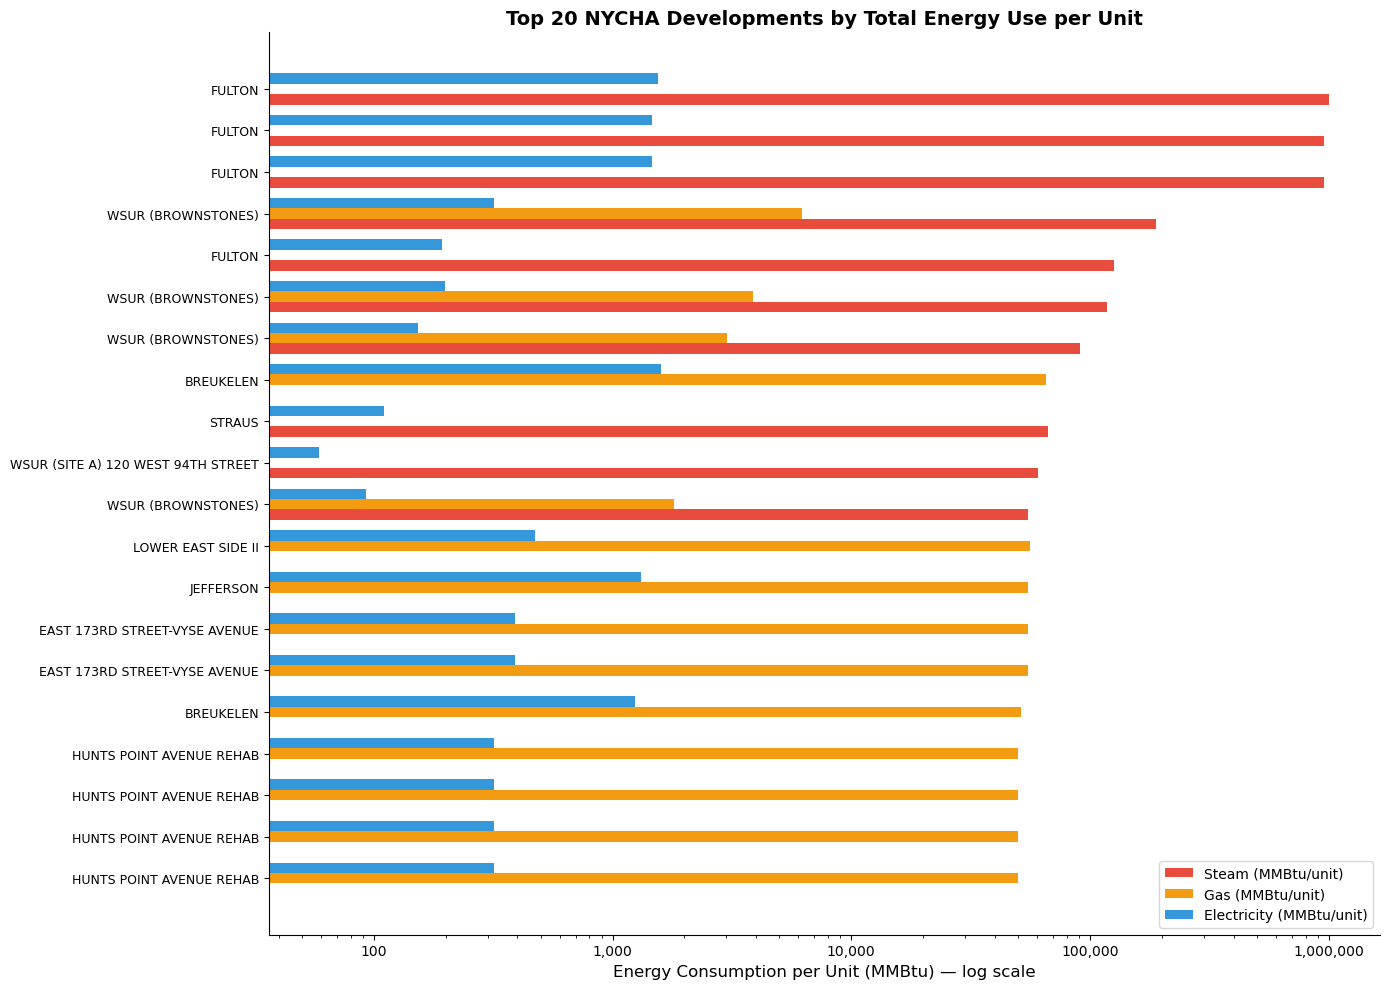

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

base = Path().resolve().parent
df = pd.read_csv(base / "cleaned_data/combined_utilities_2024.csv")

# Top 20 by total energy per unit
top20 = df.nlargest(20, 'total_energy_mmbtu_per_unit').sort_values('total_energy_mmbtu_per_unit', ascending=True)

steam_vals = top20['steam_mmbtu_per_unit'].fillna(0).values
gas_vals = top20['gas_mmbtu_per_unit'].fillna(0).values
elec_vals = top20['electricity_mmbtu_per_unit'].fillna(0).values
labels = top20['development'].values

# Grouped bar chart — log scale
fig, ax = plt.subplots(figsize=(14, 10))
y = np.arange(len(labels))
height = 0.25

ax.barh(y - height, steam_vals, height, label='Steam (MMBtu/unit)', color='#e74c3c')
ax.barh(y, gas_vals, height, label='Gas (MMBtu/unit)', color='#f39c12')
ax.barh(y + height, elec_vals, height, label='Electricity (MMBtu/unit)', color='#3498db')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Energy Consumption per Unit (MMBtu) — log scale', fontsize=12)
ax.set_title('Top 20 NYCHA Developments by Total Energy Use per Unit', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()